# 05 — Figura longitudinal tipo *stream plot* + *horizon/heatmap* para microbioma CIBIMI

Este notebook genera una figura inspirada en el ejemplo compartido:  
**Panel A:** abundancia relativa longitudinal tipo área acumulada (*stream/stacked area plot*).  
**Panel B:** mapa de calor longitudinal de taxones frecuentes, centrado por taxón para resaltar cambios sobre/bajo su abundancia típica.

Todas las figuras se guardan automáticamente en la carpeta `plots/`.

In [15]:
# ============================================================
# 0. Librerías y configuración general
# ============================================================
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_context("notebook")
sns.set_style("whitegrid")

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

# URLs del repositorio
URL_OTU = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/all_samples.tsv"
URL_METADATA = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/metadata_cibimi.csv"
URL_FUNCTION = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/output_all_levels_and_function.csv"

# Parámetros principales que puedes ajustar
TAX_LEVEL = "phylum"      # opciones: kingdom, phylum, class, order, family, genus, species
TOP_N_STREAM = 8          # número de taxones principales para panel A
TOP_N_HEATMAP = 40        # número de taxones para panel B
MIN_TOTAL_COUNT = 1       # filtra taxones con conteos totales muy bajos

# Si el notebook no detecta bien estas columnas, escríbelas aquí manualmente.
SAMPLE_COL_MANUAL = None  # ejemplo: "SampleID"
TIME_COL_MANUAL = None    # ejemplo: "day" / "edad_dias" / "timepoint"
GROUP_COL_MANUAL = None   # ejemplo: "Group" / "Subject" / "Treatment"

In [16]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_context("notebook")
sns.set_style("whitegrid")

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

# URLs del repositorio
URL_OTU = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/all_samples.tsv"
URL_METADATA = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/metadata_cibimi.csv"
URL_FUNCTION = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/output_all_levels_and_function.csv"

# Parámetros principales que puedes ajustar
TAX_LEVEL = "phylum"      # opciones: kingdom, phylum, class, order, family, genus, species
TOP_N_STREAM = 8          # número de taxones principales para panel A
TOP_N_HEATMAP = 40        # número de taxones para panel B
MIN_TOTAL_COUNT = 1       # filtra taxones con conteos totales muy bajos

# Si el notebook no detecta bien estas columnas, escríbelas aquí manualmente.
SAMPLE_COL_MANUAL = None  # ejemplo: "SampleID"
TIME_COL_MANUAL = None    # ejemplo: "day" / "edad_dias" / "timepoint"
GROUP_COL_MANUAL = None   # ejemplo: "Group" / "Subject" / "Treatment"

# ============================================================
# 1. Funciones auxiliares
# ============================================================

def clean_sample_name(x):
    """Normaliza nombres de muestra para poder unir OTU table con metadata."""
    x = str(x).strip()
    x = re.sub(r"_.*$", "", x)  # S00SO-0001_S1931_R-taxa -> S00SO-0001
    return x

def clean_plot_label(name):
    """Removes taxonomic prefixes like 'p__' or 'g__' for display and replaces 'Unclassified'."""
    if isinstance(name, str):
        cleaned_name = re.sub(r"^[a-zA-Z]__", "", name).strip()
        if cleaned_name == "": # Handle cases where only prefix existed, like "p__" becoming ""
            return "Sin clasificar"
        return cleaned_name
    return name

def read_otu_table(url):
    """Lee all_samples.tsv tolerando la línea extra tipo QIIME/BIOM si existe."""
    try:
        df = pd.read_csv(url, sep="\t", skiprows=1)
        if "#OTU ID" not in df.columns and "Consensus Lineage" not in df.columns:
            df = pd.read_csv(url, sep="\t")
    except Exception:
        df = pd.read_csv(url, sep="\t")
    return df


def parse_taxonomy(tax_series):
    """Convierte Consensus Lineage en columnas taxonómicas limpias."""
    ranks = ["kingdom", "phylum", "class", "order", "family", "genus", "species"]
    tax_split = tax_series.fillna("Unclassified").astype(str).str.split(";", expand=True)
    tax_split = tax_split.iloc[:, :len(ranks)]
    tax_split.columns = ranks[:tax_split.shape[1]]
    for col in tax_split.columns:
        tax_split[col] = (
            tax_split[col]
            .astype(str)
            .str.replace(r"^[a-zA-Z]__", "", regex=True)
            .str.strip()
            .replace({"": "Unclassified", "nan": "Unclassified", "None": "Unclassified"})
        )
    for rank in ranks:
        if rank not in tax_split.columns:
            tax_split[rank] = "Unclassified"
    return tax_split[ranks]


def prepare_taxonomic_abundance(otu_raw, tax_level="phylum"):
    """Devuelve tabla de conteos agregada por nivel taxonómico: filas=muestras, columnas=taxones."""
    otu = otu_raw.copy()
    otu = otu.rename(columns={"": "OTU_ID"})
    if "OTU_ID" not in otu.columns:
        otu.insert(0, "OTU_ID", [f"OTU_{i}" for i in range(len(otu))])
    if "Consensus Lineage" not in otu.columns:
        raise ValueError("No se encontró la columna 'Consensus Lineage' en la tabla OTU.")

    taxonomy = parse_taxonomy(otu["Consensus Lineage"])
    count_df = otu.drop(columns=["Consensus Lineage"], errors="ignore").set_index("OTU_ID")
    count_df = count_df.apply(pd.to_numeric, errors="coerce").fillna(0)

    # Agregar OTUs por nivel taxonómico y transponer a muestras x taxones
    level = tax_level.lower()
    if level not in taxonomy.columns:
        raise ValueError(f"Nivel taxonómico no válido: {tax_level}")
    grouped = count_df.groupby(taxonomy[level].values).sum()
    grouped = grouped.loc[grouped.sum(axis=1) >= MIN_TOTAL_COUNT]

    abundance = grouped.T
    abundance.index = abundance.index.map(clean_sample_name)
    abundance = abundance.groupby(abundance.index).sum()  # une réplicas si quedaron duplicadas al limpiar
    abundance.index.name = "sample_id"
    return abundance


def relative_abundance(counts):
    """Convierte conteos a abundancia relativa por muestra."""
    denom = counts.sum(axis=1).replace(0, np.nan)
    rel = counts.div(denom, axis=0).fillna(0)
    return rel


def guess_metadata_columns(metadata, sample_ids):
    """Intenta detectar columna de muestra, tiempo y grupo/sujeto."""
    md = metadata.copy()
    md.columns = [str(c).strip() for c in md.columns]

    # Sample column
    if SAMPLE_COL_MANUAL and SAMPLE_COL_MANUAL in md.columns:
        sample_col = SAMPLE_COL_MANUAL
    else:
        best_col, best_score = None, -1
        sample_set = set(map(str, sample_ids))
        for col in md.columns:
            vals = md[col].dropna().astype(str).map(clean_sample_name)
            score = vals.isin(sample_set).sum()
            if score > best_score:
                best_col, best_score = col, score
        sample_col = best_col

    # Time column
    if TIME_COL_MANUAL and TIME_COL_MANUAL in md.columns:
        time_col = TIME_COL_MANUAL
    else:
        candidates = [
            c for c in md.columns
            if any(k in c.lower() for k in ["day", "dia", "día", "edad", "age", "time", "fecha", "date", "week", "semana"])
        ]
        numeric_candidates = []
        for c in candidates:
            vals = pd.to_numeric(md[c], errors="coerce")
            if vals.notna().sum() >= max(3, len(md) * 0.2):
                numeric_candidates.append(c)
        time_col = numeric_candidates[0] if numeric_candidates else (candidates[0] if candidates else None)

    # Group/subject column
    if GROUP_COL_MANUAL and GROUP_COL_MANUAL in md.columns:
        group_col = GROUP_COL_MANUAL
    else:
        preferred = ["subject", "sujeto", "patient", "paciente", "infant", "bebe", "bebé", "sample_type", "group", "grupo", "condition", "tratamiento"]
        group_col = None
        for key in preferred:
            matches = [c for c in md.columns if key in c.lower()]
            if matches:
                group_col = matches[0]
                break

    return sample_col, time_col, group_col


def join_metadata(rel_abund, metadata):
    """Une abundancias relativas con metadata y ordena por tiempo si existe."""
    sample_col, time_col, group_col = guess_metadata_columns(metadata, rel_abund.index)
    print("Columna de muestra detectada:", sample_col)
    print("Columna de tiempo detectada:", time_col)
    print("Columna de grupo/sujeto detectada:", group_col)

    md = metadata.copy()
    md["sample_id_clean"] = md[sample_col].map(clean_sample_name)
    md = md.drop_duplicates("sample_id_clean").set_index("sample_id_clean")

    common = rel_abund.index.intersection(md.index)
    if len(common) == 0:
        raise ValueError("No hubo coincidencias entre muestras de OTU table y metadata. Revisa SAMPLE_COL_MANUAL.")

    rel = rel_abund.loc[common].copy()
    md_common = md.loc[common].copy()
    joined = rel.join(md_common, how="left")

    if time_col is not None:
        joined["__time__"] = pd.to_numeric(joined[time_col], errors="coerce")
        if joined["__time__"].notna().sum() == 0:
            joined["__time__"] = pd.to_datetime(joined[time_col], errors="coerce")
        joined = joined.sort_values("__time__")
    else:
        joined["__time__"] = np.arange(len(joined))
        joined = joined.sort_values("__time__")

    if group_col is None:
        joined["__group__"] = "Todos"
        group_col = "__group__"

    return joined, sample_col, time_col, group_col

In [17]:
# ============================================================
# 2. Cargar y preparar datos
# ============================================================
metadata = pd.read_csv(URL_METADATA)
otu_raw = read_otu_table(URL_OTU)

# Rellenar NaN en 'Weeks of gestation' por cada bebé
# Asumimos que 'Baby number' identifica a cada individuo.
if 'Weeks of gestation' in metadata.columns and 'Baby number' in metadata.columns:
    metadata['Weeks of gestation'] = metadata.groupby('Baby number')['Weeks of gestation'].transform(lambda x: x.ffill().bfill())
    print("NaNs en 'Weeks of gestation' rellenos por 'Baby number'.")

abund_counts = prepare_taxonomic_abundance(otu_raw, tax_level=TAX_LEVEL)
rel_abund = relative_abundance(abund_counts)

joined, sample_col, time_col, group_col = join_metadata(rel_abund, metadata)

taxon_cols = rel_abund.columns.tolist()
print("Metadata:", metadata.shape)
print("OTU raw:", otu_raw.shape)
print("Abundancia relativa:", rel_abund.shape)
print("Muestras con metadata:", joined.shape[0])
display(joined.head())

NaNs en 'Weeks of gestation' rellenos por 'Baby number'.
Columna de muestra detectada: MBI Sample ID
Columna de tiempo detectada: Weeks of gestation
Columna de grupo/sujeto detectada: Group
Metadata: (86, 16)
OTU raw: (10794, 108)
Abundancia relativa: (93, 78)
Muestras con metadata: 83


,p__,p__Acidobacteriota,p__Actinomycetota,p__Apicomplexa,p__Aquificota,p__Armatimonadota,p__Ascomycota,p__Atribacterota,p__Bacillariophyta,p__Bacillota,...,Sex,Weight,Size,Head Circunference,Abdominal Circunference,Necrotizing enterocolitis,Type of Birth,Clasification birth weight,Week,__time__
S00SO-0025,0.003831,0.000000e+00,0.004643,0.000018,0.0,0.000000,0.000071,0.0,0.0,0.020885,...,fem,1120.0,33.0,25.0,23.5,No presence,Cesarean,NaN,2,9.0
S00SO-0024,0.004463,0.000000e+00,0.020802,0.000000,0.0,0.000000,0.000288,0.0,0.0,0.080976,...,fem,790.0,33.0,23.0,17.0,No presence,Cesarean,Extremely low,1,9.0
S00SO-0020,0.002547,0.000000e+00,0.000712,0.000015,0.0,0.000003,0.000052,0.0,0.0,0.021463,...,masc,740.0,28.0,23.0,19.0,No presence,Parturition,Extremely low,2,26.0
S00SO-0019,0.000257,4.688661e-07,0.000121,0.000024,0.0,0.000000,0.000002,0.0,0.0,0.000590,...,masc,770.0,30.0,24.0,20.0,No presence,Parturition,Extremely low,1,26.0
S00SO-0021,0.001259,0.000000e+00,0.005795,0.000210,0.0,0.000000,0.853693,0.0,0.0,0.053751,...,masc,755.0,28.0,23.0,19.0,No presence,Parturition,Extremely low,3,26.0


In [18]:
# ============================================================
# 3. Seleccionar taxones principales y preparar matrices
# ============================================================
# Taxones más abundantes para el stream plot
top_stream = rel_abund[taxon_cols].mean(axis=0).sort_values(ascending=False).head(TOP_N_STREAM).index.tolist()
stream_df = joined[top_stream].copy()
stream_df["Other"] = joined[taxon_cols].drop(columns=top_stream, errors="ignore").sum(axis=1)
stream_df["__time__"] = joined["__time__"].values
stream_df[group_col] = joined[group_col].astype(str).values

# Taxones principales para heatmap/horizon simplificado
top_heatmap = rel_abund[taxon_cols].mean(axis=0).sort_values(ascending=False).head(TOP_N_HEATMAP).index.tolist()
heat_raw = joined[top_heatmap].copy()

# Transformación tipo horizon: centrar cada taxón por su mediana y escalar por MAD
# Valores positivos = más abundante que su mediana; negativos = menos abundante que su mediana.
median = heat_raw.median(axis=0)
mad = (heat_raw - median).abs().median(axis=0).replace(0, np.nan)
heat_centered = (heat_raw - median).div(mad, axis=1).replace([np.inf, -np.inf], np.nan).fillna(0)
heat_centered = heat_centered.clip(-4, 4)

# Etiquetas de eje X
x_labels = joined["__time__"].astype(str).tolist()
print("Taxones panel A:", top_stream + ["Other"])
print("Taxones panel B:", len(top_heatmap))

Taxones panel A: ['p__Pseudomonadota', 'p__Bacillota', 'p__Bacteroidota', 'p__Chordata', 'p__Actinomycetota', 'p__Ascomycota', 'p__Mycoplasmatota', 'p__', 'Other']
Taxones panel B: 40


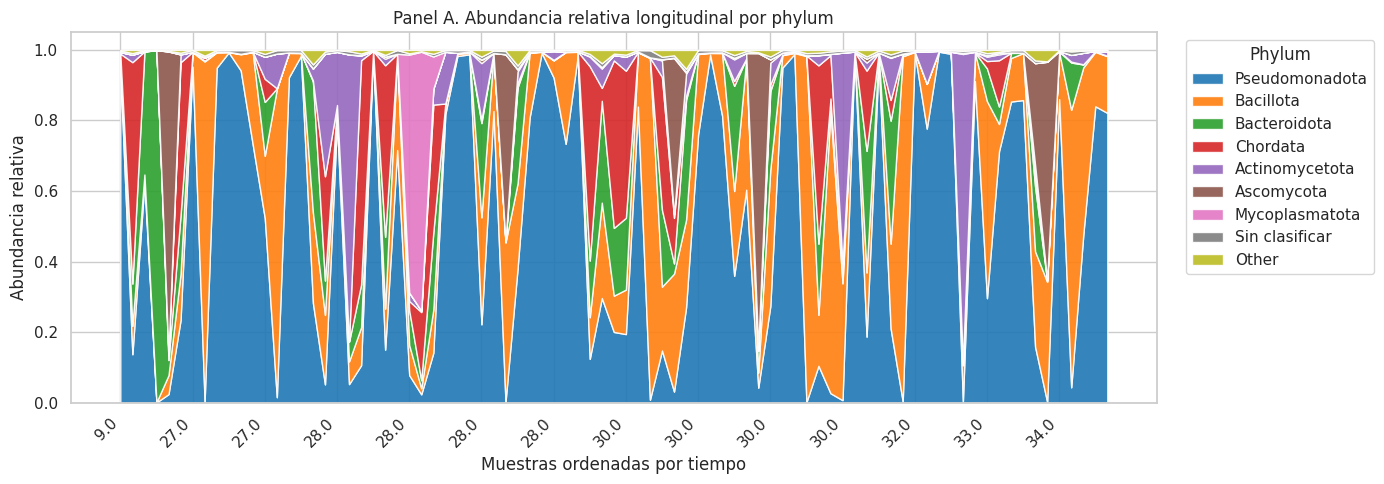

Figura guardada en: plots/streamplot_phylum_over_time.png


In [19]:
# ============================================================
# 4. Panel A — Stream/stacked area plot general
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(stream_df.shape[0])
y = stream_df[top_stream + ["Other"]].T.values
ax.stackplot(x, y, labels=[clean_plot_label(t) for t in top_stream + ["Other"]], alpha=0.9)

ax.set_title(f"Panel A. Abundancia relativa longitudinal por {TAX_LEVEL}")
ax.set_xlabel("Muestras ordenadas por tiempo")
ax.set_ylabel("Abundancia relativa")

# Mostrar pocas etiquetas para no saturar
step = max(1, len(x) // 12)
ax.set_xticks(x[::step])
ax.set_xticklabels([x_labels[i] for i in x[::step]], rotation=45, ha="right")
ax.legend(title=clean_plot_label(TAX_LEVEL.capitalize()), bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

out = PLOTS_DIR / f"streamplot_{TAX_LEVEL}_over_time.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print("Figura guardada en:", out)

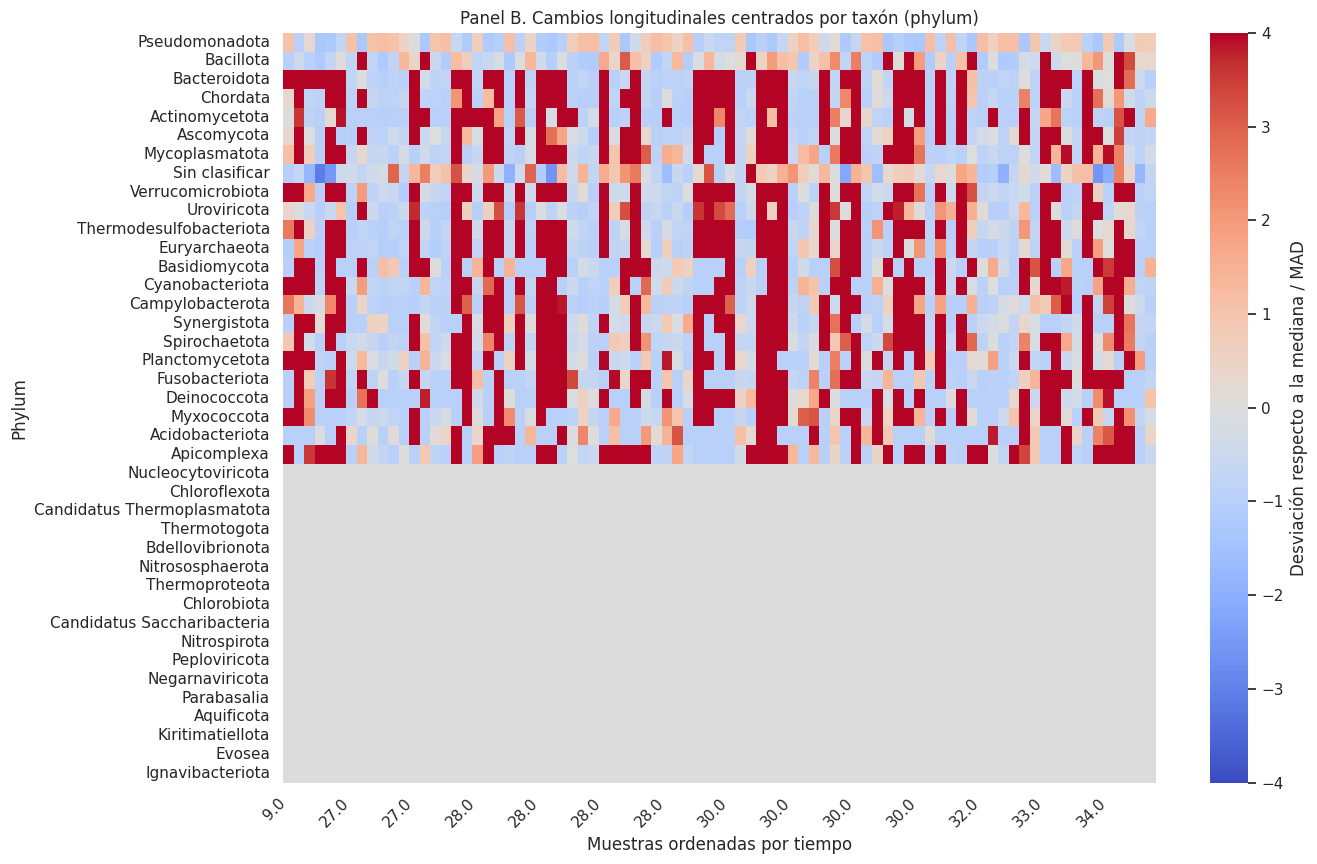

Figura guardada en: plots/heatmap_horizon_phylum_over_time.png


In [20]:
# ============================================================
# 5. Panel B — Heatmap tipo horizon simplificado
# ============================================================
fig, ax = plt.subplots(figsize=(14, max(6, TOP_N_HEATMAP * 0.22)))

sns.heatmap(
    heat_centered.T,
    cmap="coolwarm",
    center=0,
    vmin=-4,
    vmax=4,
    ax=ax,
    cbar_kws={"label": "Desviación respecto a la mediana / MAD"},
    yticklabels=[clean_plot_label(t) for t in heat_centered.T.index.tolist()]
)

ax.set_title(f"Panel B. Cambios longitudinales centrados por taxón ({TAX_LEVEL})")
ax.set_xlabel("Muestras ordenadas por tiempo")
ax.set_ylabel(clean_plot_label(TAX_LEVEL.capitalize()))

step = max(1, len(x_labels) // 12)
ax.set_xticks(np.arange(0.5, len(x_labels), step))
ax.set_xticklabels([x_labels[i] for i in range(0, len(x_labels), step)], rotation=45, ha="right")
plt.tight_layout()

out = PLOTS_DIR / f"heatmap_horizon_{TAX_LEVEL}_over_time.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print("Figura guardada en:", out)

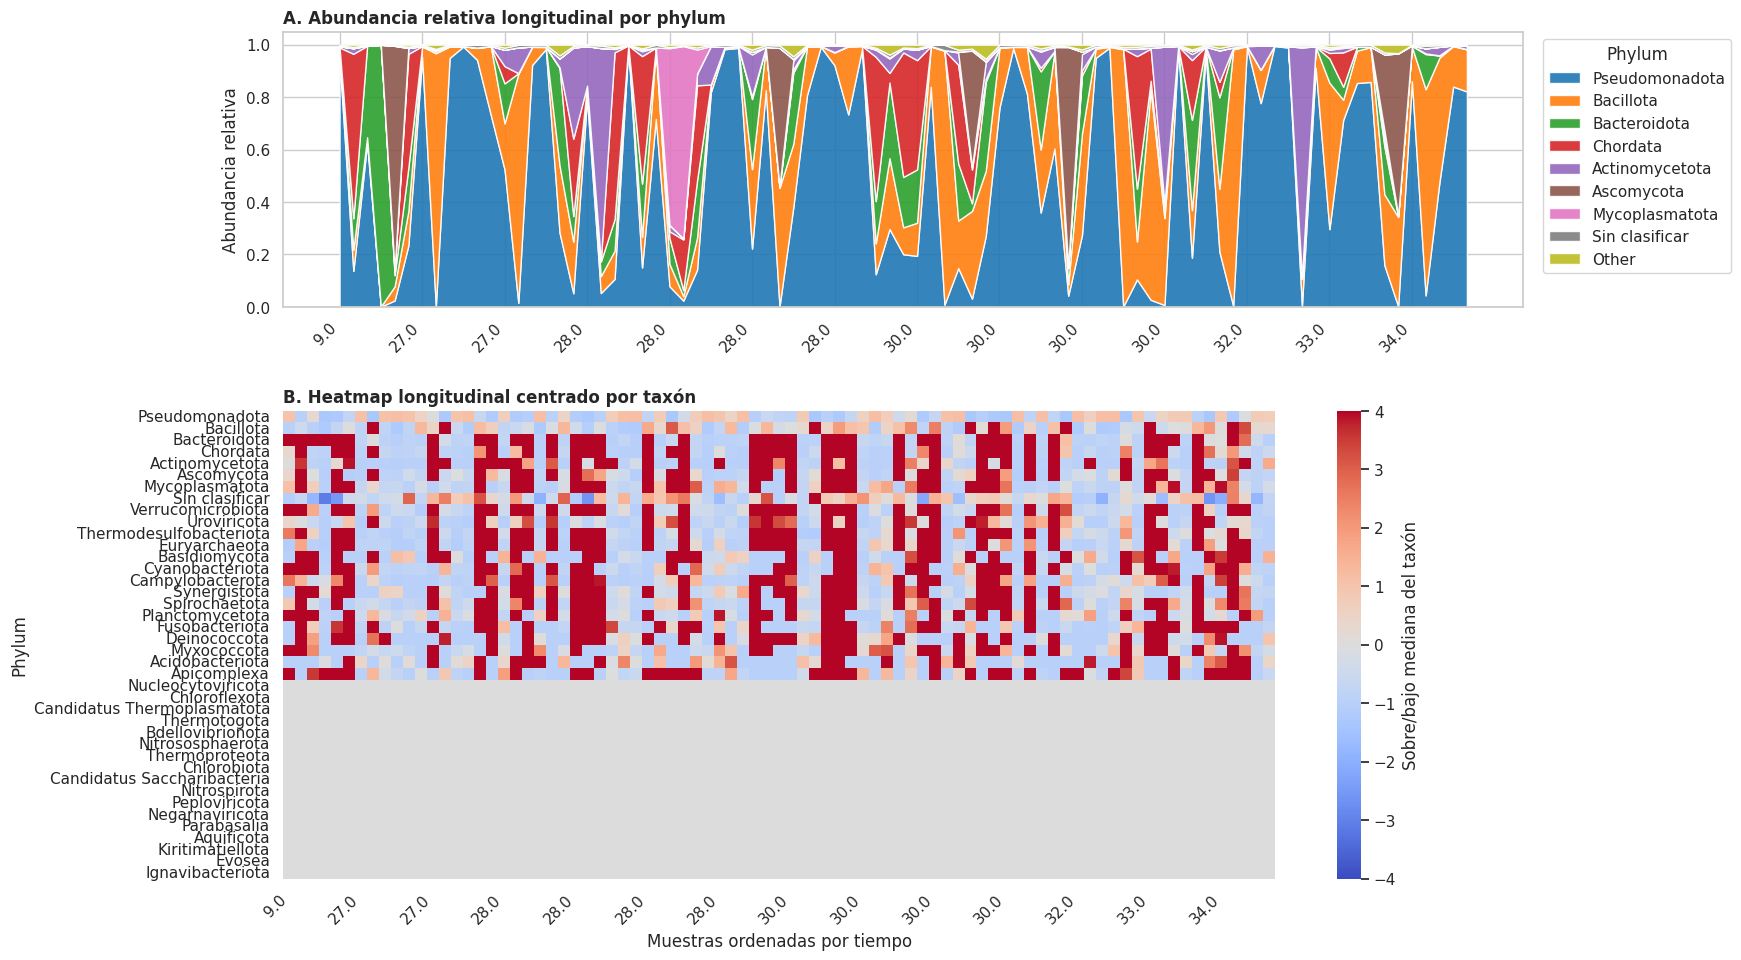

Figura guardada en: plots/combined_longitudinal_microbiome_phylum.png


In [21]:
# ============================================================
# 6. Figura combinada estilo paper: Panel A + Panel B
# ============================================================
fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.7], hspace=0.28)

# Panel A
ax1 = fig.add_subplot(gs[0, 0])
ax1.stackplot(x, y, labels=[clean_plot_label(t) for t in top_stream + ["Other"]], alpha=0.9)
ax1.set_title(f"A. Abundancia relativa longitudinal por {TAX_LEVEL}", loc="left", fontweight="bold")
ax1.set_ylabel("Abundancia relativa")
ax1.set_xticks(x[::step])
ax1.set_xticklabels([x_labels[i] for i in x[::step]], rotation=45, ha="right")
ax1.legend(title=clean_plot_label(TAX_LEVEL.capitalize()), bbox_to_anchor=(1.01, 1), loc="upper left")

# Panel B
ax2 = fig.add_subplot(gs[1, 0])
sns.heatmap(
    heat_centered.T,
    cmap="coolwarm",
    center=0,
    vmin=-4,
    vmax=4,
    ax=ax2,
    cbar_kws={"label": "Sobre/bajo mediana del taxón"},
    yticklabels=[clean_plot_label(t) for t in heat_centered.T.index.tolist()]
)
ax2.set_title("B. Heatmap longitudinal centrado por taxón", loc="left", fontweight="bold")
ax2.set_xlabel("Muestras ordenadas por tiempo")
ax2.set_ylabel(clean_plot_label(TAX_LEVEL.capitalize()))
ax2.set_xticks(np.arange(0.5, len(x_labels), step))
ax2.set_xticklabels([x_labels[i] for i in range(0, len(x_labels), step)], rotation=45, ha="right")

plt.tight_layout()
out = PLOTS_DIR / f"combined_longitudinal_microbiome_{TAX_LEVEL}.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print("Figura guardada en:", out)

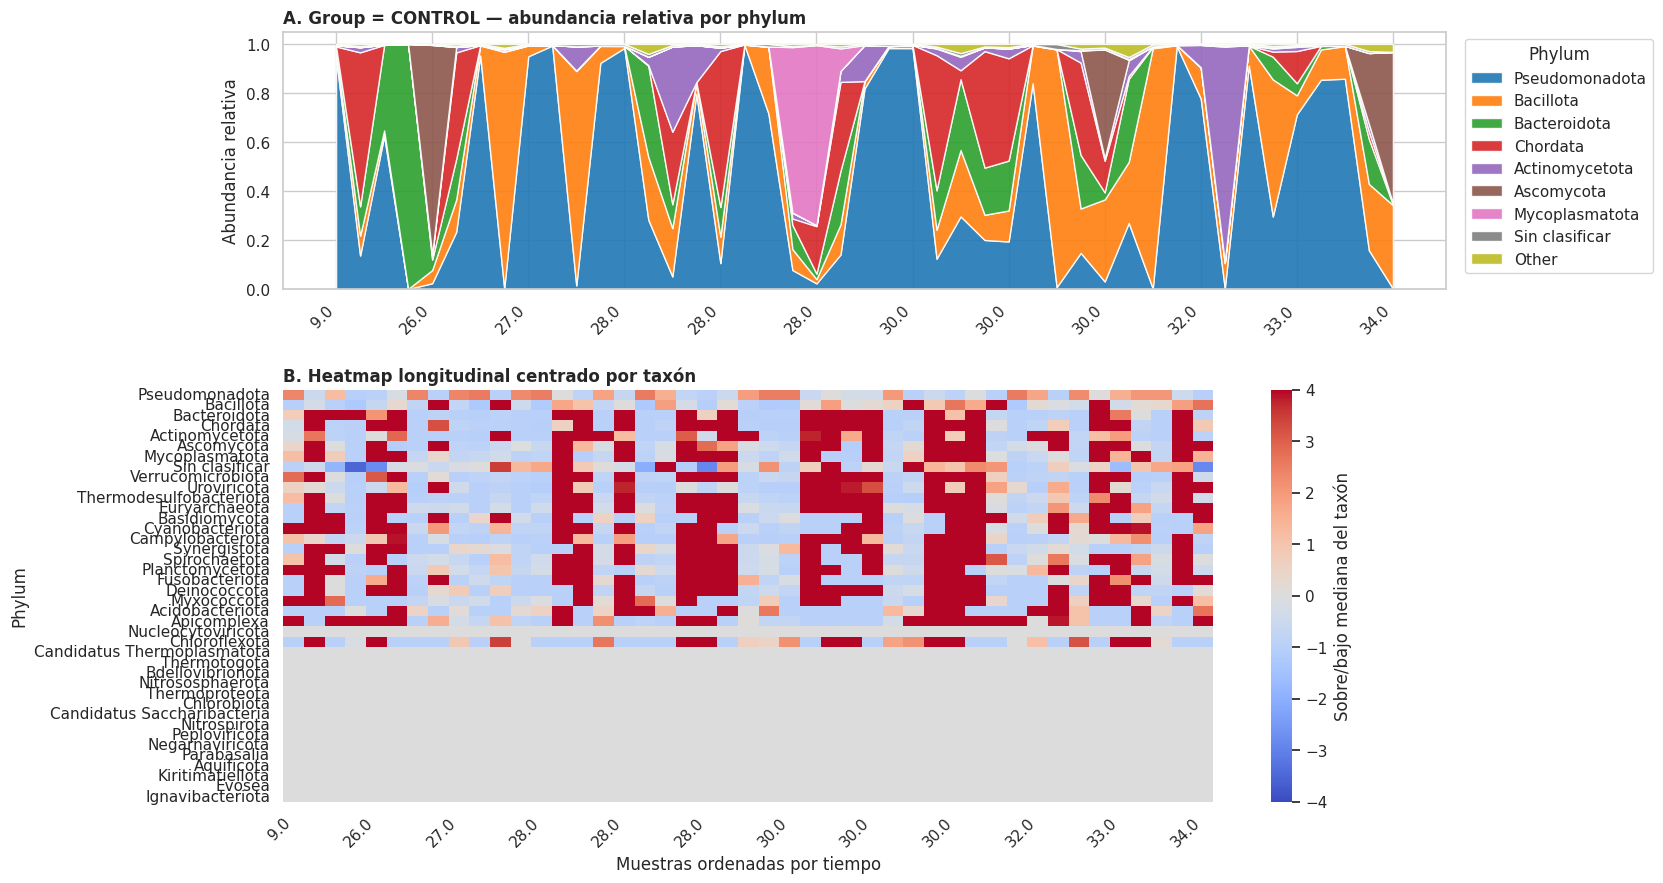

Figura guardada en: plots/combined_longitudinal_phylum_Group_CONTROL.png


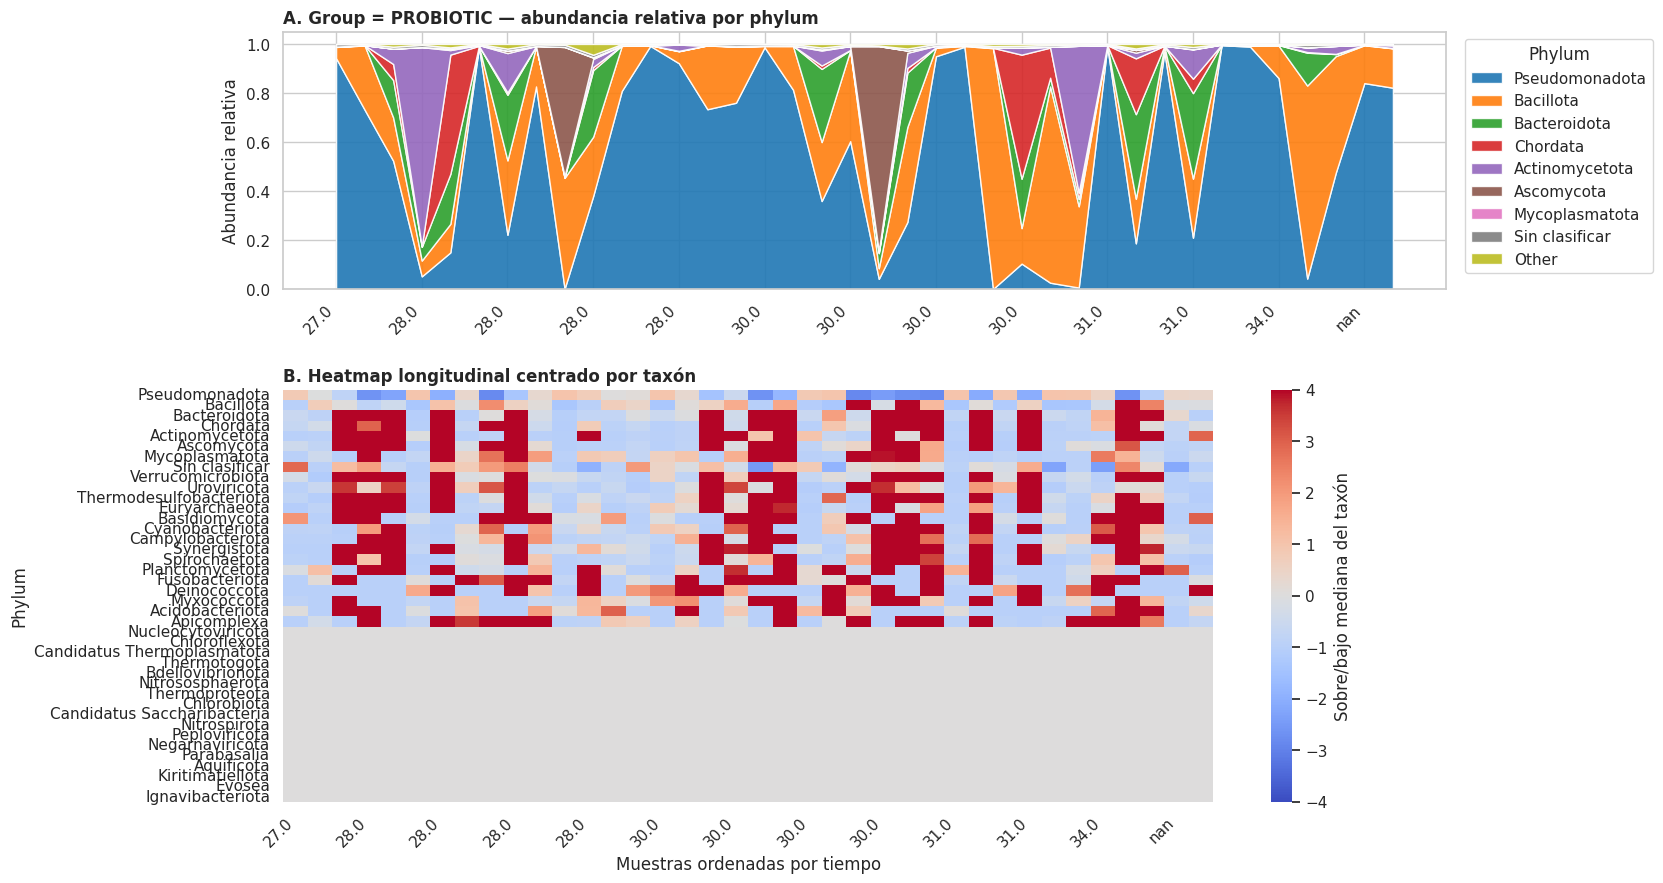

Figura guardada en: plots/combined_longitudinal_phylum_Group_PROBIOTIC.png


In [22]:
# ============================================================
# 7. Opcional — generar la figura por grupo/sujeto si existe una columna útil
# ============================================================
# Esto crea una figura combinada por cada grupo/sujeto con al menos 3 muestras.

make_by_group = True
min_samples_per_group = 3

if make_by_group and group_col is not None:
    for group_value, sub in joined.groupby(group_col):
        if sub.shape[0] < min_samples_per_group:
            continue

        sub = sub.sort_values("__time__")
        sub_stream = sub[top_stream].copy()
        sub_stream["Other"] = sub[taxon_cols].drop(columns=top_stream, errors="ignore").sum(axis=1)
        sub_x = np.arange(sub.shape[0])
        sub_y = sub_stream[top_stream + ["Other"]].T.values
        sub_labels = sub["__time__"].astype(str).tolist()
        sub_heat = sub[top_heatmap].copy()
        sub_median = sub_heat.median(axis=0)
        sub_mad = (sub_heat - sub_median).abs().median(axis=0).replace(0, np.nan)
        sub_centered = (sub_heat - sub_median).div(sub_mad, axis=1).replace([np.inf, -np.inf], np.nan).fillna(0).clip(-4, 4)

        fig = plt.figure(figsize=(15, 10))
        gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.6], hspace=0.3)

        ax1 = fig.add_subplot(gs[0, 0])
        ax1.stackplot(sub_x, sub_y, labels=[clean_plot_label(t) for t in top_stream + ["Other"]], alpha=0.9)
        ax1.set_title(f"A. {group_col} = {group_value} — abundancia relativa por {TAX_LEVEL}", loc="left", fontweight="bold")
        ax1.set_ylabel("Abundancia relativa")
        sub_step = max(1, len(sub_x) // 10)
        ax1.set_xticks(sub_x[::sub_step])
        ax1.set_xticklabels([sub_labels[i] for i in sub_x[::sub_step]], rotation=45, ha="right")
        ax1.legend(title=clean_plot_label(TAX_LEVEL.capitalize()), bbox_to_anchor=(1.01, 1), loc="upper left")

        ax2 = fig.add_subplot(gs[1, 0])
        sns.heatmap(sub_centered.T, cmap="coolwarm", center=0, vmin=-4, vmax=4, ax=ax2,
                    cbar_kws={"label": "Sobre/bajo mediana del taxón"},
                    yticklabels=[clean_plot_label(t) for t in sub_centered.T.index.tolist()])
        ax2.set_title("B. Heatmap longitudinal centrado por taxón", loc="left", fontweight="bold")
        ax2.set_xlabel("Muestras ordenadas por tiempo")
        ax2.set_ylabel(clean_plot_label(TAX_LEVEL.capitalize()))
        ax2.set_xticks(np.arange(0.5, len(sub_labels), sub_step))
        ax2.set_xticklabels([sub_labels[i] for i in range(0, len(sub_labels), sub_step)], rotation=45, ha="right")

        safe_group = re.sub(r"[^A-Za-z0-9_-]+", "_", str(group_value))[:60]
        out = PLOTS_DIR / f"combined_longitudinal_{TAX_LEVEL}_{group_col}_{safe_group}.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()
        print("Figura guardada en:", out)

In [23]:
# Cargar la tabla OTU raw
otu_raw_kingdom_check = read_otu_table(URL_OTU)

# Parsear la taxonomía para obtener el nivel de reino
taxonomy_kingdom = parse_taxonomy(otu_raw_kingdom_check['Consensus Lineage'])

# Obtener los reinos únicos presentes en los datos
unique_kingdoms = taxonomy_kingdom['kingdom'].unique().tolist()

print("Reinos taxonómicos presentes en las muestras:")
print(unique_kingdoms)

# Verificar si hay reinos diferentes de 'Bacteria'
non_bacteria_kingdoms = [k for k in unique_kingdoms if k.lower() != 'bacteria']

if non_bacteria_kingdoms:
    print("\nSí, existen taxones que no pertenecen al reino Bacteria. Estos son:")
    print(non_bacteria_kingdoms)
else:
    print("\nNo, todos los taxones presentes pertenecen al reino Bacteria.")

Reinos taxonómicos presentes en las muestras:
['Bacteria', 'Archaea', 'Eukaryota', 'Viruses', 'Unclassified']

Sí, existen taxones que no pertenecen al reino Bacteria. Estos son:
['Archaea', 'Eukaryota', 'Viruses', 'Unclassified']


## Notas de interpretación

- En el **Panel A**, cada color representa un taxón y el área representa su abundancia relativa en cada muestra ordenada temporalmente.
- En el **Panel B**, los colores cálidos indican momentos donde el taxón está por encima de su abundancia típica; los colores fríos indican valores por debajo de su mediana.
- Si la columna de tiempo o grupo no se detecta correctamente, modifica `TIME_COL_MANUAL`, `SAMPLE_COL_MANUAL` o `GROUP_COL_MANUAL` en la primera celda de configuración.